In [1]:
print("\n" + "=" * 70)
print("TARGET T-ALL UMAP DIMENSIONALITY REDUCTION & CLUSTERING PROFILE")
print("=" * 70)


TARGET T-ALL UMAP DIMENSIONALITY REDUCTION & CLUSTERING PROFILE


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test, logrank_test
import umap
import hdbscan
import warnings, os
 
warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 10,
    'axes.titlesize': 11, 'figure.facecolor': 'white'
})

import os
os.chdir("/Users/Meralle/PyCharmMiscProject/T-ALL Analysis")

In [3]:
INPUT_CSV = "09_TARGET_model_ready.csv"
COX_DIR     = "TARGET_univariate_cox_outputs"
OUTPUT_DIR  = "TARGET_umap_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
# Survival endpoints
PRIMARY_DURATION = "OS"
PRIMARY_EVENT    = "OS.status"
ALL_ENDPOINTS    = [
    ("OS",  "OS.status",  "Overall Survival"),
    ("EFS", "EFS.status", "Event-Free Survival"),
    ("DFS", "DFS.status", "Disease-Free Survival"),
]

In [4]:
UMAP_CONFIGS = [
    {"n_neighbors": 10, "min_dist": 0.1,  "label": "local_tight"},
    {"n_neighbors": 15, "min_dist": 0.1,  "label": "default"},       # UMAP default
    {"n_neighbors": 30, "min_dist": 0.3,  "label": "global_loose"},
    {"n_neighbors": 15, "min_dist": 0.05, "label": "default_tighter"},
]
RANDOM_STATE = 42

HDBSCAN_MIN_CLUSTER = 10   # minimum patients to form a cluster
KMEANS_K_RANGE      = range(2, 7)   # test k=2 to 6 clusters

In [5]:
print("=" * 70)
print("STEP 0: LOAD DATA & RECOVER COLUMN NAMES FROM COX NOTEBOOK")
print("=" * 70)

#the variable names were cleaned in the Cox notebook. e.g. Day.29.MRD became "Day 29 MRD"
#need to reverse this to get back the actual df column names

df = pd.read_csv(INPUT_CSV)
print(f"  Data shape: {df.shape[0]} patients × {df.shape[1]} columns")
 
# ── Coerce survival columns ──
for dur, evt, _ in ALL_ENDPOINTS:
    if dur in df.columns:
        df[dur] = pd.to_numeric(df[dur], errors='coerce')
    if evt in df.columns:
        df[evt] = pd.to_numeric(df[evt], errors='coerce')

df['ETP.STATUS'] = df['ETP.STATUS'].map({'ETP': 0, 'Near-ETP': 1, 'Non-ETP': 2})

CONTINUOUS_VARS = [
    "Age.at.Diagnosis.in.Years",
    "WBC_log",                                  # log1p(WBC) — used in Cox
    "Percent.Blasts.Tumor.Sample.Diagnostic",
    "Germline.with.Tumor.Contamination.%.Blasts"
]

BINARY_ORDINAL_VARS = [
    "Sex",
    "ETP.STATUS",
    "Had_Relapse_Specimen",
    "In.TARGET.Cohort.(n=.264).RNASeq.and.WES",
]

known_non_feature = (
    CONTINUOUS_VARS + BINARY_ORDINAL_VARS +
    [d for d, e, _ in ALL_ENDPOINTS] +
    [e for d, e, _ in ALL_ENDPOINTS] +
    ["USI", "patient_id",
     "Day29_MRD_tested", "Death_recorded",
     "Day.29.MRD",                    # post-treatment, excluded
     "End.of.Consolidation.MRD",      # post-treatment, excluded
     "Day.29.morphologic.Response"]   # post-treatment, excluded
)
dummy_cols = [
    c for c in df.columns
    if c not in known_non_feature
    and "_" in c
    and df[c].dtype in ['int64', 'float64', 'int32', 'uint8']
    and df[c].nunique() <= 3
    and not c.startswith("Event.Type_")        # always outcomes
    and not c.startswith("Germline.Specimen.")  # admin/sample type
    and not c.startswith("Tumor.Specimen.")     # admin/sample type
]

# Define intentionally excluded columns (outcomes / post-treatment / admin)
EXCLUDED_BY_DESIGN = set(
    [c for c in df.columns if c.startswith("Event.Type_")]
    + [c for c in df.columns if c.startswith("Germline.Specimen.")]
    + [c for c in df.columns if c.startswith("Tumor.Specimen.")]
    + ["Day.29.MRD", "End.of.Consolidation.MRD", "Day.29.morphologic.Response"]
)

# Build reverse lookup from cleaned name → original col name
# (only for candidate feature columns)
excluded_lookup = {}
for col in EXCLUDED_BY_DESIGN:
    cleaned = col.replace(".", " ").replace("_", " ").strip().lower()
    excluded_lookup[cleaned] = col

def load_sig_vars(endpoint_safe_label):
    """Load significant variable names from Cox output, reverse name cleaning."""
    path = f"{COX_DIR}/05_significant_vars_{endpoint_safe_label}.csv"
    if not os.path.exists(path):
        print(f"  ⚠ Cox output not found: {path} — using all candidate vars")
        return None
    sig_display = pd.read_csv(path)['variable'].tolist()

    all_candidates = CONTINUOUS_VARS + BINARY_ORDINAL_VARS + dummy_cols
    lookup = {}
    for col in all_candidates:
        cleaned = col.replace(".", " ").replace("_", " ").strip().lower()
        lookup[cleaned] = col

    recovered = []
    not_found = []
    excluded_found = []        # <-- new bucket
    for display_name in sig_display:
        key = display_name.strip().lower()
        if key in lookup:
            recovered.append(lookup[key])
        elif key in excluded_lookup:
            excluded_found.append(display_name)   # intentionally excluded
        else:
            not_found.append(display_name)         # genuinely missing

    if excluded_found:
        print(f"  ℹ Intentionally excluded from UMAP (outcome/post-treatment/admin): {excluded_found}")
    if not_found:
        print(f"  ⚠ Could not recover df columns for: {not_found}")
    return recovered
 
sig_os  = load_sig_vars("Overall_Survival_OS")
sig_efs = load_sig_vars("Event-Free_Survival_EFS")
sig_dfs = load_sig_vars("Disease-Free_Survival_DFS")

sig_union = list(dict.fromkeys(
    (sig_os or []) + (sig_efs or []) + (sig_dfs or [])
))
sig_union = [c for c in sig_union if c in df.columns]

if not sig_union:
    print("  Falling back to all candidate variables (no Cox outputs found)")
    sig_union = [c for c in CONTINUOUS_VARS + BINARY_ORDINAL_VARS + dummy_cols
                 if c in df.columns]
 
print(f"\n  Significant variables for UMAP ({len(sig_union)}):")
for v in sig_union:
    print(f"    {v}")

STEP 0: LOAD DATA & RECOVER COLUMN NAMES FROM COX NOTEBOOK
  Data shape: 1335 patients × 30 columns
  ℹ Intentionally excluded from UMAP (outcome/post-treatment/admin): ['Day 29 MRD']
  ℹ Intentionally excluded from UMAP (outcome/post-treatment/admin): ['Day 29 MRD']
  ℹ Intentionally excluded from UMAP (outcome/post-treatment/admin): ['Day 29 MRD']
  Falling back to all candidate variables (no Cox outputs found)

  Significant variables for UMAP (7):
    Age.at.Diagnosis.in.Years
    WBC_log
    Percent.Blasts.Tumor.Sample.Diagnostic
    Germline.with.Tumor.Contamination.%.Blasts
    Sex
    ETP.STATUS
    Had_Relapse_Specimen


In [6]:
print("\n" + "=" * 70)
print("STEP 1: PREPARE FEATURE MATRIX")
print("=" * 70)


STEP 1: PREPARE FEATURE MATRIX


In [7]:
# Keep only patients with survival data available
df_model = df.dropna(subset=[PRIMARY_DURATION, PRIMARY_EVENT]).copy()
print(f"  Patients with complete survival data: {len(df_model)}")

  Patients with complete survival data: 1335


In [8]:
# Build feature matrix from significant variables
feature_cols = [c for c in sig_union if c in df_model.columns]
X_raw = df_model[feature_cols].copy()

# Coerce all to numeric (some encoded cols may still be object)
for col in feature_cols:
    X_raw[col] = pd.to_numeric(X_raw[col], errors='coerce')

print(f"  Feature matrix shape: {X_raw.shape}")
print(f"  Missing values per feature:")
missing_pct = X_raw.isna().mean() * 100
for col, pct in missing_pct[missing_pct > 0].items():
    print(f"    {col}: {pct:.1f}% missing")

  Feature matrix shape: (1335, 7)
  Missing values per feature:
    Percent.Blasts.Tumor.Sample.Diagnostic: 2.3% missing
    Germline.with.Tumor.Contamination.%.Blasts: 99.4% missing
    ETP.STATUS: 14.5% missing


In [9]:
#median imputation replaces missing values with middle of each column
#safer than using mean because extreme outliers won't skew
#for binary/ordinal columns, median will land on most common value anyway
#so one strategy works for all column types

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_raw)
X_imputed = pd.DataFrame(X_imputed, columns=feature_cols,
                          index=X_raw.index)

#RobustScaler: subtracts median, divides by IQR
#not sensitive to the extreme WBC outliers that exist in T-ALL
#StandardScaler would let these outliers pull the mean and inflate variance
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_imputed)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols,
                             index=X_imputed.index)

print(f"\n  Feature matrix ready: {X_scaled.shape[0]} patients × "
      f"{X_scaled.shape[1]} features")
print(f"  Scaler: RobustScaler (median=0, IQR=1)")


  Feature matrix ready: 1335 patients × 7 features
  Scaler: RobustScaler (median=0, IQR=1)



  PCA variance explained:
    2 components : 68.4%
    5 components : 96.0%


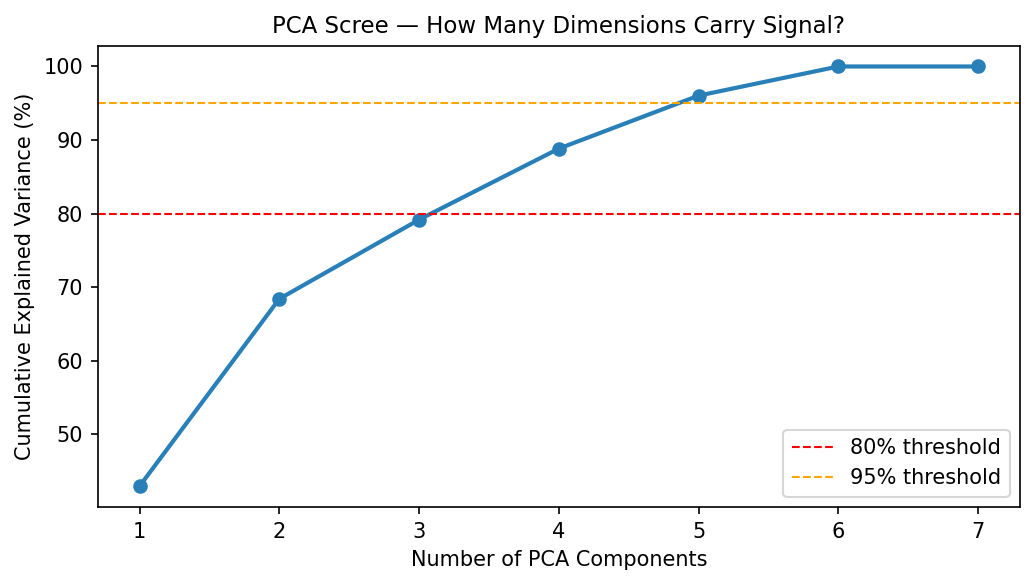


  PCA scree plot → TARGET_umap_outputs/01_pca_scree.png


In [11]:
#Quick PCA check before UMAP
#if 2 PCA components explain >80% of variance, the data is 2D already
#UMAP will just confirm that structure. If variance is spread across many 
#components, UMAP is doing meaningful work 

pca_check = PCA(n_components=min(X_scaled.shape[1], 10))
pca_check.fit(X_scaled)
cum_var = np.cumsum(pca_check.explained_variance_ratio_)
print(f"\n  PCA variance explained:")
print(f"    2 components : {cum_var[1]*100:.1f}%")
print(f"    5 components : {cum_var[min(4, len(cum_var)-1)]*100:.1f}%")
if len(cum_var) >= 10:
    print(f"    10 components: {cum_var[9]*100:.1f}%")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cum_var)+1), cum_var*100, 'o-', color='#2980B9', lw=2)
ax.axhline(80, color='red', ls='--', lw=1, label='80% threshold')
ax.axhline(95, color='orange', ls='--', lw=1, label='95% threshold')
ax.set_xlabel("Number of PCA Components")
ax.set_ylabel("Cumulative Explained Variance (%)")
ax.set_title("PCA Scree — How Many Dimensions Carry Signal?")
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig(f"{OUTPUT_DIR}/01_pca_scree.png", bbox_inches='tight')
plt.close()
print(f"\n  PCA scree plot → {OUTPUT_DIR}/01_pca_scree.png")


In [12]:
print("\n" + "=" * 70)
print("STEP 2: RUN UMAP")
print("=" * 70)


STEP 2: RUN UMAP


  Running UMAP: n_neighbors=10, min_dist=0.1 (local_tight)...
    Done. Embedding range: x=[-4.94, 15.01], y=[-0.88, 13.12]
  Running UMAP: n_neighbors=15, min_dist=0.1 (default)...
    Done. Embedding range: x=[-4.58, 12.61], y=[-3.78, 7.97]
  Running UMAP: n_neighbors=30, min_dist=0.3 (global_loose)...
    Done. Embedding range: x=[-3.16, 9.21], y=[0.79, 13.19]
  Running UMAP: n_neighbors=15, min_dist=0.05 (default_tighter)...
    Done. Embedding range: x=[-3.92, 12.78], y=[-3.52, 8.76]


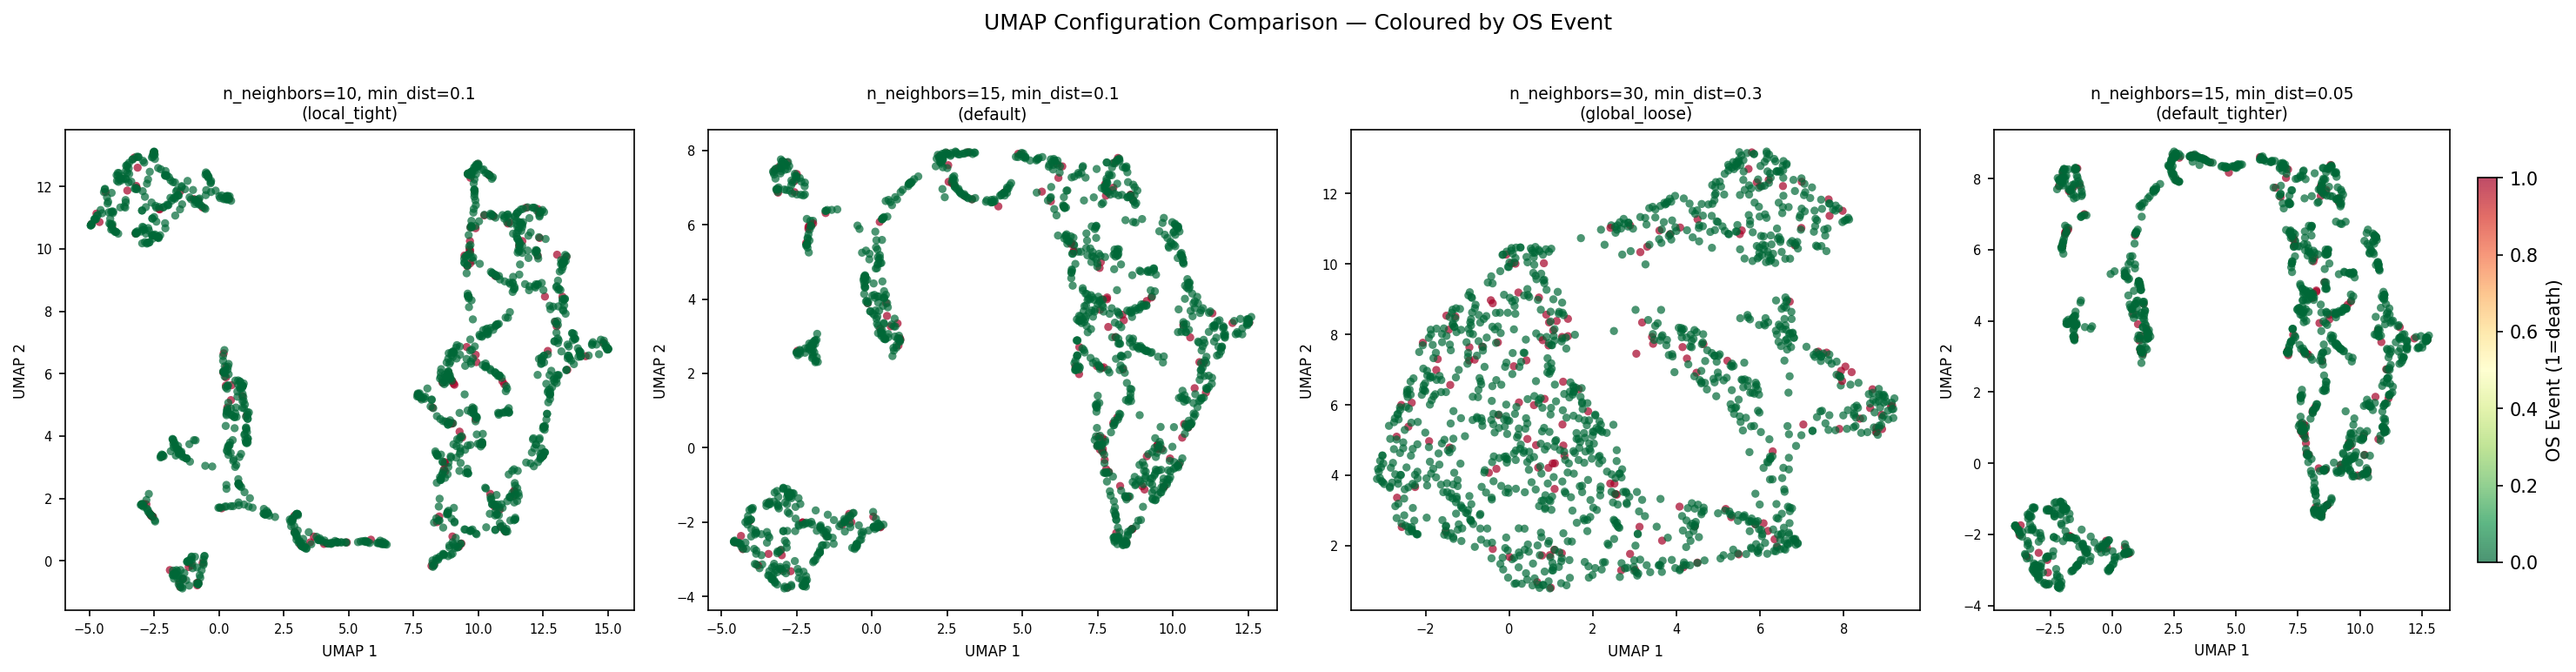


  Config comparison plot → TARGET_umap_outputs/02_umap_config_comparison.png

  Primary embedding: 'default' (n_neighbors=15, min_dist=0.1)


In [13]:
embeddings = {}   # config label → (n_patients, 2) array
 
for cfg in UMAP_CONFIGS:
    print(f"  Running UMAP: n_neighbors={cfg['n_neighbors']}, "
          f"min_dist={cfg['min_dist']} ({cfg['label']})...")
 
    reducer = umap.UMAP(
        n_neighbors  = cfg['n_neighbors'],
        min_dist     = cfg['min_dist'],
        n_components = 2,
        metric       = 'euclidean',
        random_state = RANDOM_STATE,
        # n_epochs=500 for more stable embeddings on small datasets (<500 pts)
        n_epochs     = 500,
        # low_memory=False: use full memory for reproducibility
        low_memory   = False,
    )
    embedding = reducer.fit_transform(X_scaled)
    embeddings[cfg['label']] = embedding
    print(f"    Done. Embedding range: "
          f"x=[{embedding[:,0].min():.2f}, {embedding[:,0].max():.2f}], "
          f"y=[{embedding[:,1].min():.2f}, {embedding[:,1].max():.2f}]")

# ── Plot all configurations side by side ──
# Colour by OS event to immediately see if separation corresponds to survival
fig, axes = plt.subplots(1, len(UMAP_CONFIGS),
                          figsize=(len(UMAP_CONFIGS)*5, 5))
os_event = df_model[PRIMARY_EVENT].values
 
for ax, (label, emb) in zip(axes, embeddings.items()):
    cfg_meta = next(c for c in UMAP_CONFIGS if c['label'] == label)
    scatter = ax.scatter(emb[:, 0], emb[:, 1],
                         c=os_event, cmap='RdYlGn_r',
                         s=20, alpha=0.7, edgecolors='none')
    ax.set_title(f"n_neighbors={cfg_meta['n_neighbors']}, "
                 f"min_dist={cfg_meta['min_dist']}\n({label})",
                 fontsize=9)
    ax.set_xlabel("UMAP 1", fontsize=8)
    ax.set_ylabel("UMAP 2", fontsize=8)
    ax.tick_params(labelsize=7)

plt.colorbar(scatter, ax=axes[-1], label='OS Event (1=death)', shrink=0.8)
plt.suptitle("UMAP Configuration Comparison — Coloured by OS Event",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
plt.savefig(f"{OUTPUT_DIR}/02_umap_config_comparison.png",
            bbox_inches='tight')
plt.close()
print(f"\n  Config comparison plot → {OUTPUT_DIR}/02_umap_config_comparison.png")
 
# ── Select primary embedding (default UMAP parameters are well-validated) ──
PRIMARY_CONFIG = "default"
emb_primary = embeddings[PRIMARY_CONFIG]
print(f"\n  Primary embedding: '{PRIMARY_CONFIG}' "
      f"(n_neighbors=15, min_dist=0.1)")
 
# Add UMAP coordinates to working dataframe
df_model = df_model.copy()
df_model["UMAP1"] = emb_primary[:, 0]
df_model["UMAP2"] = emb_primary[:, 1]

In [14]:
# Check in the original df before any filtering
print("ETP.STATUS unique values:", df['ETP.STATUS'].unique())
print("ETP.STATUS non-null count:", df['ETP.STATUS'].notna().sum())
print()
print("CNS.Status unique values:", df['CNS.Status'].unique())
print("CNS.Status non-null count:", df['CNS.Status'].notna().sum())

ETP.STATUS unique values: [ 2.  0.  1. nan]
ETP.STATUS non-null count: 1141

CNS.Status unique values: [nan]
CNS.Status non-null count: 0


In [15]:
print("\n" + "=" * 70)
print("STEP 3: CLUSTER THE UMAP EMBEDDING")
print("=" * 70)


STEP 3: CLUSTER THE UMAP EMBEDDING


In [16]:
print("  HDBSCAN clustering...")
hdb = hdbscan.HDBSCAN(
    min_cluster_size = HDBSCAN_MIN_CLUSTER,
    min_samples      = 5,        # how conservative the outlier detection is
    cluster_selection_epsilon = 0.5,  # merge nearby micro-clusters
    prediction_data  = True,
)
hdb_labels = hdb.fit_predict(emb_primary)
n_hdb_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise        = (hdb_labels == -1).sum()
print(f"    HDBSCAN: {n_hdb_clusters} clusters, {n_noise} noise points "
      f"({n_noise/len(hdb_labels)*100:.1f}%)")
 
if n_hdb_clusters >= 2:
    valid_mask = hdb_labels != -1
    sil_hdb = silhouette_score(emb_primary[valid_mask], hdb_labels[valid_mask])
    print(f"    Silhouette score (excluding noise): {sil_hdb:.3f}")
 
df_model["HDBSCAN_cluster"] = hdb_labels

  HDBSCAN clustering...
    HDBSCAN: 8 clusters, 8 noise points (0.6%)
    Silhouette score (excluding noise): 0.458


In [17]:
print("\n  K-Means optimisation...")
kmeans_results = []
 
for k in KMEANS_K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    # n_init=20: run 20 random initialisations to avoid local minima
    km_labels = km.fit_predict(emb_primary)
    sil = silhouette_score(emb_primary, km_labels)
    db  = davies_bouldin_score(emb_primary, km_labels)
    kmeans_results.append({"k": k, "silhouette": sil,
                            "davies_bouldin": db, "labels": km_labels})
    print(f"    k={k}: silhouette={sil:.3f}, Davies-Bouldin={db:.3f}")


  K-Means optimisation...
    k=2: silhouette=0.543, Davies-Bouldin=0.759
    k=3: silhouette=0.577, Davies-Bouldin=0.600
    k=4: silhouette=0.514, Davies-Bouldin=0.680
    k=5: silhouette=0.503, Davies-Bouldin=0.703
    k=6: silhouette=0.496, Davies-Bouldin=0.753


In [18]:
best_km = max(kmeans_results, key=lambda x: x['silhouette'])
BEST_K  = best_km['k']
km_best_labels = best_km['labels']
print(f"\n  Best K-Means: k={BEST_K} "
      f"(silhouette={best_km['silhouette']:.3f})")
 
df_model["KMeans_cluster"] = km_best_labels


  Best K-Means: k=3 (silhouette=0.577)


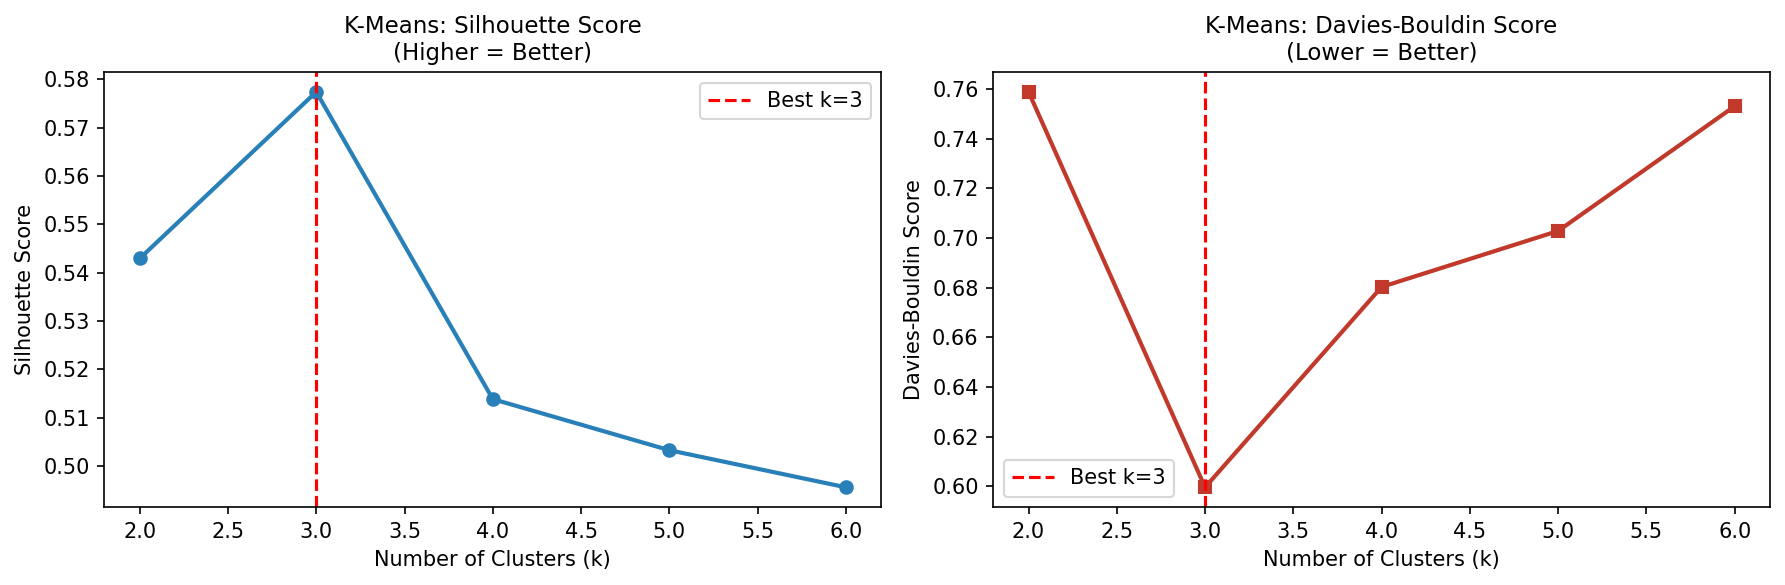

  Cluster optimisation plot → TARGET_umap_outputs/03_cluster_optimisation.png

  K-Means cluster sizes:
    Cluster 0: n=710, OS event rate=10.8%
    Cluster 1: n=247, OS event rate=8.9%
    Cluster 2: n=378, OS event rate=11.1%


In [19]:
#silhouette plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ks   = [r['k'] for r in kmeans_results]
sils = [r['silhouette'] for r in kmeans_results]
dbs  = [r['davies_bouldin'] for r in kmeans_results]
 
axes[0].plot(ks, sils, 'o-', color='#2980B9', lw=2)
axes[0].axvline(BEST_K, color='red', ls='--', lw=1.5,
                label=f'Best k={BEST_K}')
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Silhouette Score")
axes[0].set_title("K-Means: Silhouette Score\n(Higher = Better)")
axes[0].legend()
 
axes[1].plot(ks, dbs, 's-', color='#C0392B', lw=2)
axes[1].axvline(BEST_K, color='red', ls='--', lw=1.5, label=f'Best k={BEST_K}')
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Davies-Bouldin Score")
axes[1].set_title("K-Means: Davies-Bouldin Score\n(Lower = Better)")
axes[1].legend()
 
plt.tight_layout()
plt.show()
plt.savefig(f"{OUTPUT_DIR}/03_cluster_optimisation.png", bbox_inches='tight')
plt.close()
print(f"  Cluster optimisation plot → {OUTPUT_DIR}/03_cluster_optimisation.png")
 
# ── Cluster size report ──
print("\n  K-Means cluster sizes:")
for cluster_id, count in pd.Series(km_best_labels).value_counts().sort_index().items():
    event_rate = df_model[df_model["KMeans_cluster"] == cluster_id][PRIMARY_EVENT].mean()
    print(f"    Cluster {cluster_id}: n={count}, "
          f"OS event rate={event_rate*100:.1f}%")

In [20]:
print("\n" + "=" * 70)
print("STEP 4: OVERLAY KNOWN CLINICAL VARIABLES ON UMAP")
print("=" * 70)


STEP 4: OVERLAY KNOWN CLINICAL VARIABLES ON UMAP


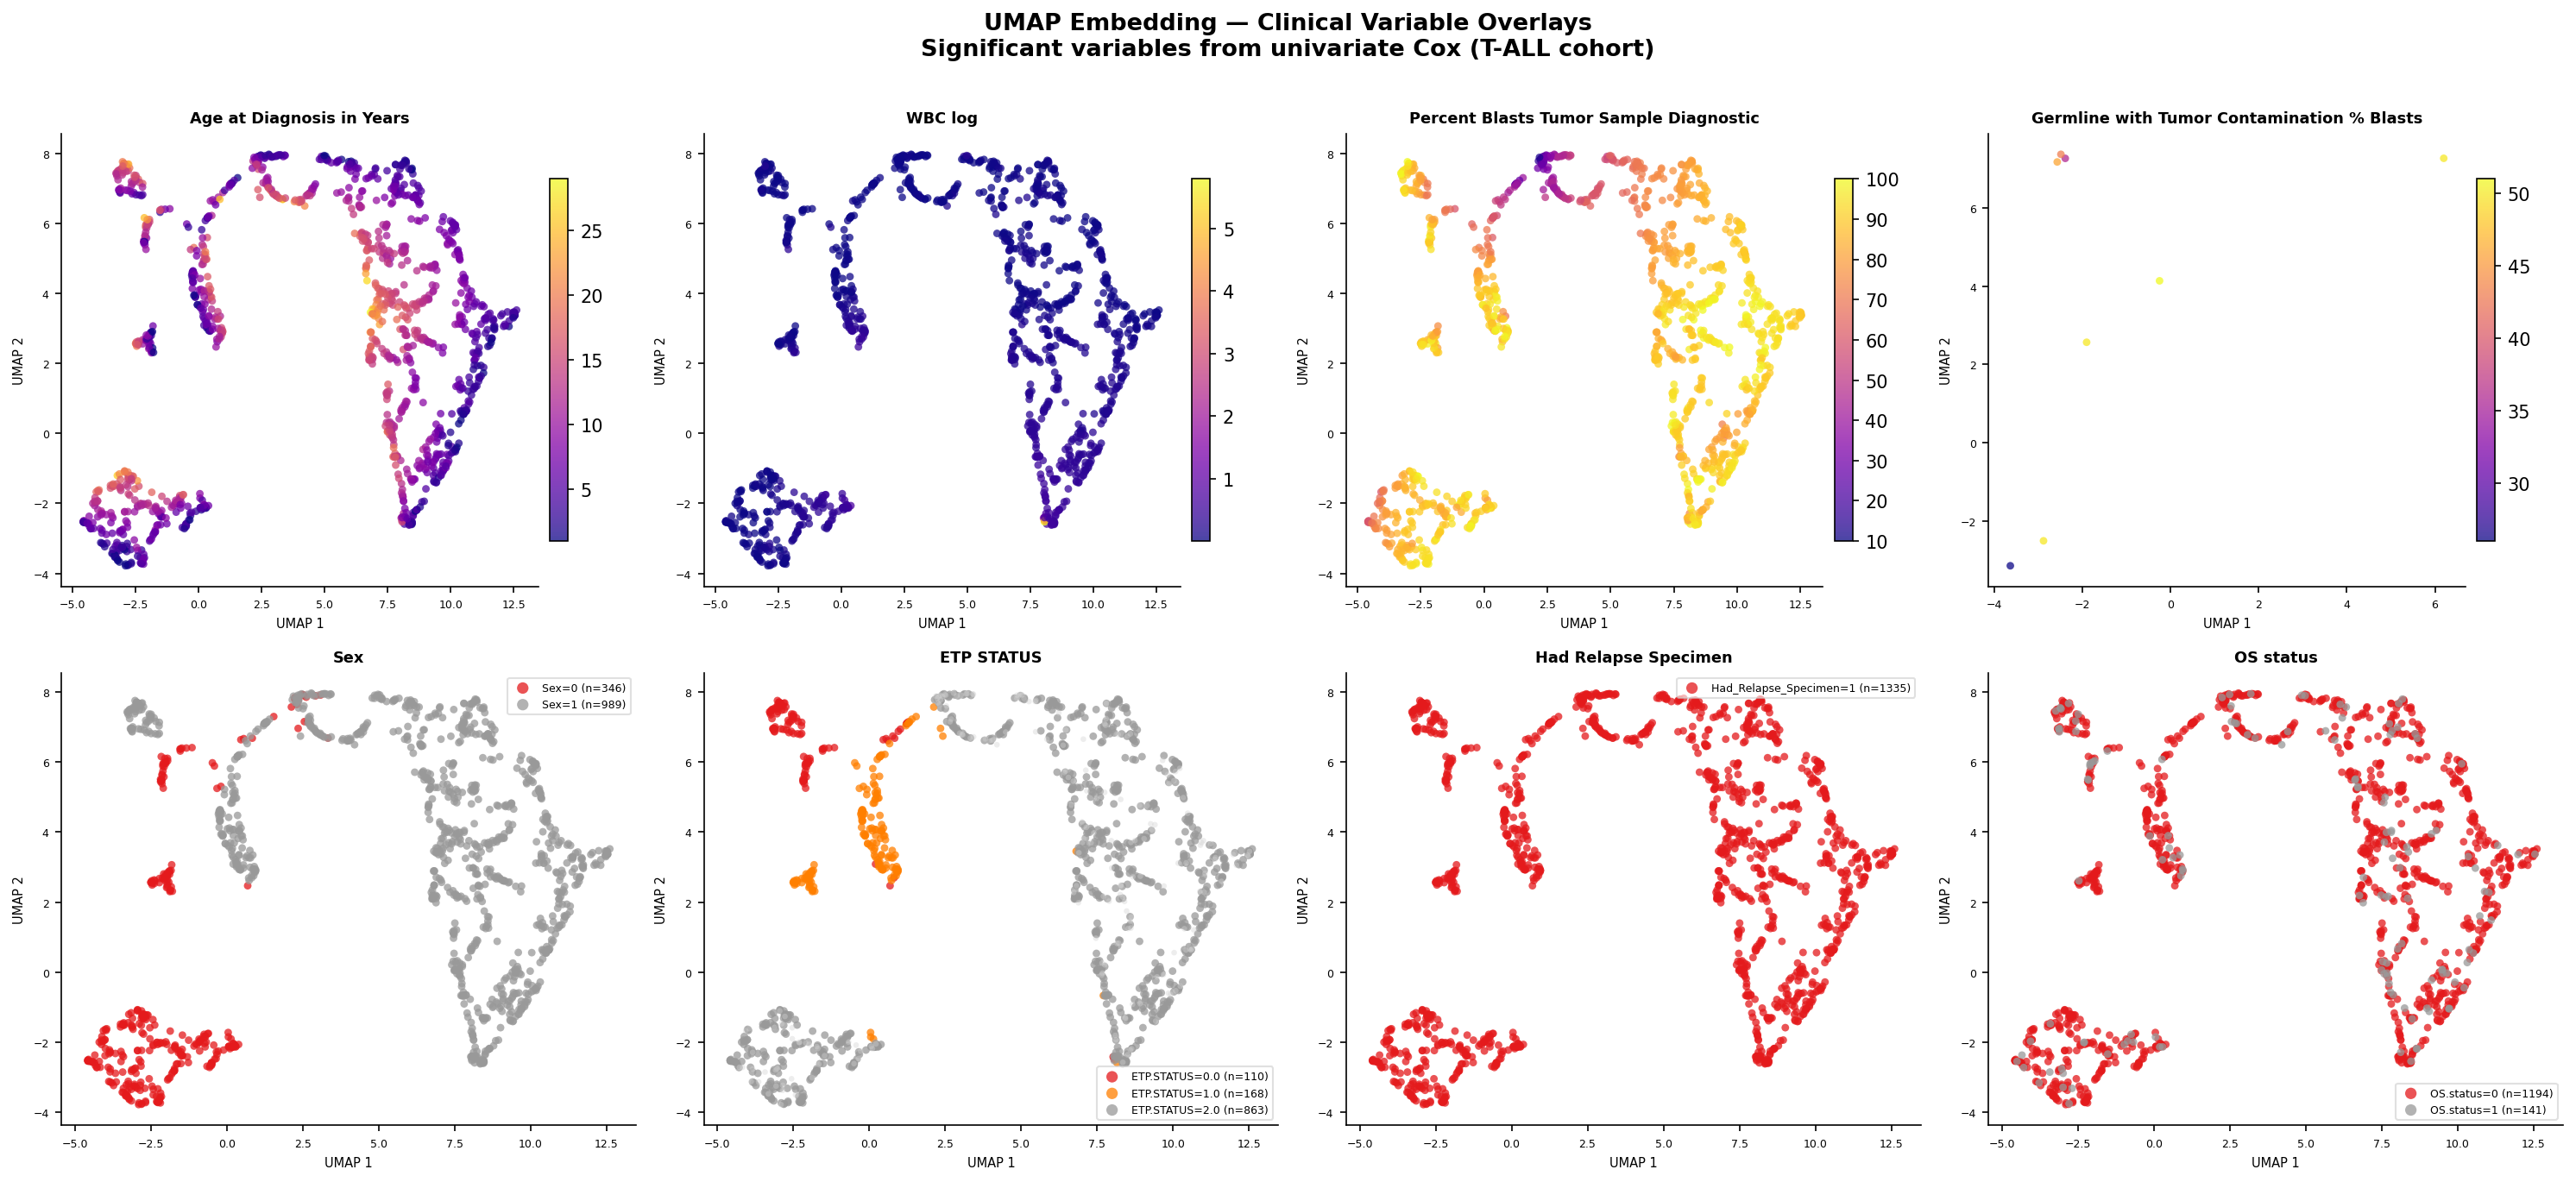

  Clinical overlay plot → TARGET_umap_outputs/04_umap_clinical_overlays.png
  Cluster overlay plot → TARGET_umap_outputs/04_umap_clusters.png


In [21]:
# Variables to overlay — both the Cox significant ones and key clinical vars
OVERLAY_VARS = sig_union + [PRIMARY_EVENT]
# Deduplicate while preserving order
OVERLAY_VARS = list(dict.fromkeys(OVERLAY_VARS))
OVERLAY_VARS = [v for v in OVERLAY_VARS if v in df_model.columns]
 
n_overlays = len(OVERLAY_VARS)
ncols = 4
nrows = int(np.ceil(n_overlays / ncols))
fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 5, nrows * 4.5))
axes = np.array(axes).flatten()
 
for i, var in enumerate(OVERLAY_VARS):
    ax = axes[i]
    values = pd.to_numeric(df_model[var], errors='coerce')
    n_unique = values.nunique()
 
    if n_unique <= 5:
        # Categorical overlay — discrete colour palette
        cmap = plt.cm.get_cmap('Set1', n_unique)
        unique_vals = sorted(values.dropna().unique())
        for j, val in enumerate(unique_vals):
            mask = values == val
            label = f"{var}={val} (n={mask.sum()})"
            ax.scatter(df_model.loc[mask, "UMAP1"],
                       df_model.loc[mask, "UMAP2"],
                       c=[cmap(j)], s=18, alpha=0.75,
                       label=label, edgecolors='none')
        ax.legend(fontsize=6, markerscale=1.5, loc='best',
                  framealpha=0.6)
        # NaN points in grey
        nan_mask = values.isna()
        if nan_mask.any():
            ax.scatter(df_model.loc[nan_mask, "UMAP1"],
                       df_model.loc[nan_mask, "UMAP2"],
                       c='lightgrey', s=10, alpha=0.4,
                       label='Missing', edgecolors='none')
    else:
        # Continuous overlay — gradient colourmap
        scatter = ax.scatter(df_model["UMAP1"], df_model["UMAP2"],
                             c=values, cmap='plasma',
                             s=18, alpha=0.75, edgecolors='none')
        plt.colorbar(scatter, ax=ax, shrink=0.8, pad=0.02)
 
    clean_name = var.replace(".", " ").replace("_", " ")
    ax.set_title(clean_name, fontsize=8.5, fontweight='bold')
    ax.set_xlabel("UMAP 1", fontsize=7)
    ax.set_ylabel("UMAP 2", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.spines[['top', 'right']].set_visible(False)
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle(
    "UMAP Embedding — Clinical Variable Overlays\n"
    "Significant variables from univariate Cox (T-ALL cohort)",
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()
plt.savefig(f"{OUTPUT_DIR}/04_umap_clinical_overlays.png",
            bbox_inches='tight', dpi=150)
plt.close()
print(f"  Clinical overlay plot → {OUTPUT_DIR}/04_umap_clinical_overlays.png")
 
# ── Dedicated cluster overlay panel ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
 
# K-Means clusters
CLUSTER_COLORS = ['#2980B9', '#C0392B', '#27AE60',
                  '#F39C12', '#8E44AD', '#1ABC9C']
for cluster_id in sorted(df_model["KMeans_cluster"].unique()):
    mask = df_model["KMeans_cluster"] == cluster_id
    n    = mask.sum()
    er   = df_model.loc[mask, PRIMARY_EVENT].mean()
    axes[0].scatter(
        df_model.loc[mask, "UMAP1"],
        df_model.loc[mask, "UMAP2"],
        c=CLUSTER_COLORS[cluster_id % len(CLUSTER_COLORS)],
        s=30, alpha=0.8, edgecolors='white', linewidths=0.3,
        label=f"Cluster {cluster_id} (n={n}, OS event={er*100:.0f}%)"
    )
axes[0].set_title(f"K-Means Clusters (k={BEST_K})", fontsize=11,
                   fontweight='bold')
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[0].legend(fontsize=8, framealpha=0.8)
axes[0].spines[['top', 'right']].set_visible(False)
 
# HDBSCAN clusters
hdb_unique = sorted(set(hdb_labels))
hdb_cmap   = plt.cm.get_cmap('tab10', max(len(hdb_unique), 1))
for idx, cluster_id in enumerate(hdb_unique):
    mask  = df_model["HDBSCAN_cluster"] == cluster_id
    n     = mask.sum()
    color = 'lightgrey' if cluster_id == -1 else hdb_cmap(idx)
    label = (f"Noise (n={n})" if cluster_id == -1
             else f"Cluster {cluster_id} (n={n})")
    axes[1].scatter(
        df_model.loc[mask, "UMAP1"],
        df_model.loc[mask, "UMAP2"],
        c=[color], s=30, alpha=0.8,
        edgecolors='white', linewidths=0.3, label=label
    )
axes[1].set_title(f"HDBSCAN Clusters "
                   f"(min_size={HDBSCAN_MIN_CLUSTER})",
                   fontsize=11, fontweight='bold')
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].legend(fontsize=8, framealpha=0.8)
axes[1].spines[['top', 'right']].set_visible(False)
 
plt.suptitle("UMAP — Unsupervised Patient Clusters", fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_umap_clusters.png",
            bbox_inches='tight', dpi=150)
plt.close()
print(f"  Cluster overlay plot → {OUTPUT_DIR}/04_umap_clusters.png")

In [22]:
print("\n" + "=" * 70)
print("STEP 5: SURVIVAL ANALYSIS OF UMAP-DERIVED CLUSTERS")
print("=" * 70)


STEP 5: SURVIVAL ANALYSIS OF UMAP-DERIVED CLUSTERS


  K-Means (k=3) | Overall Survival: log-rank p=0.4332
  K-Means (k=3) | Event-Free Survival: log-rank p=0.4169
  K-Means (k=3) | Disease-Free Survival: log-rank p=0.9339


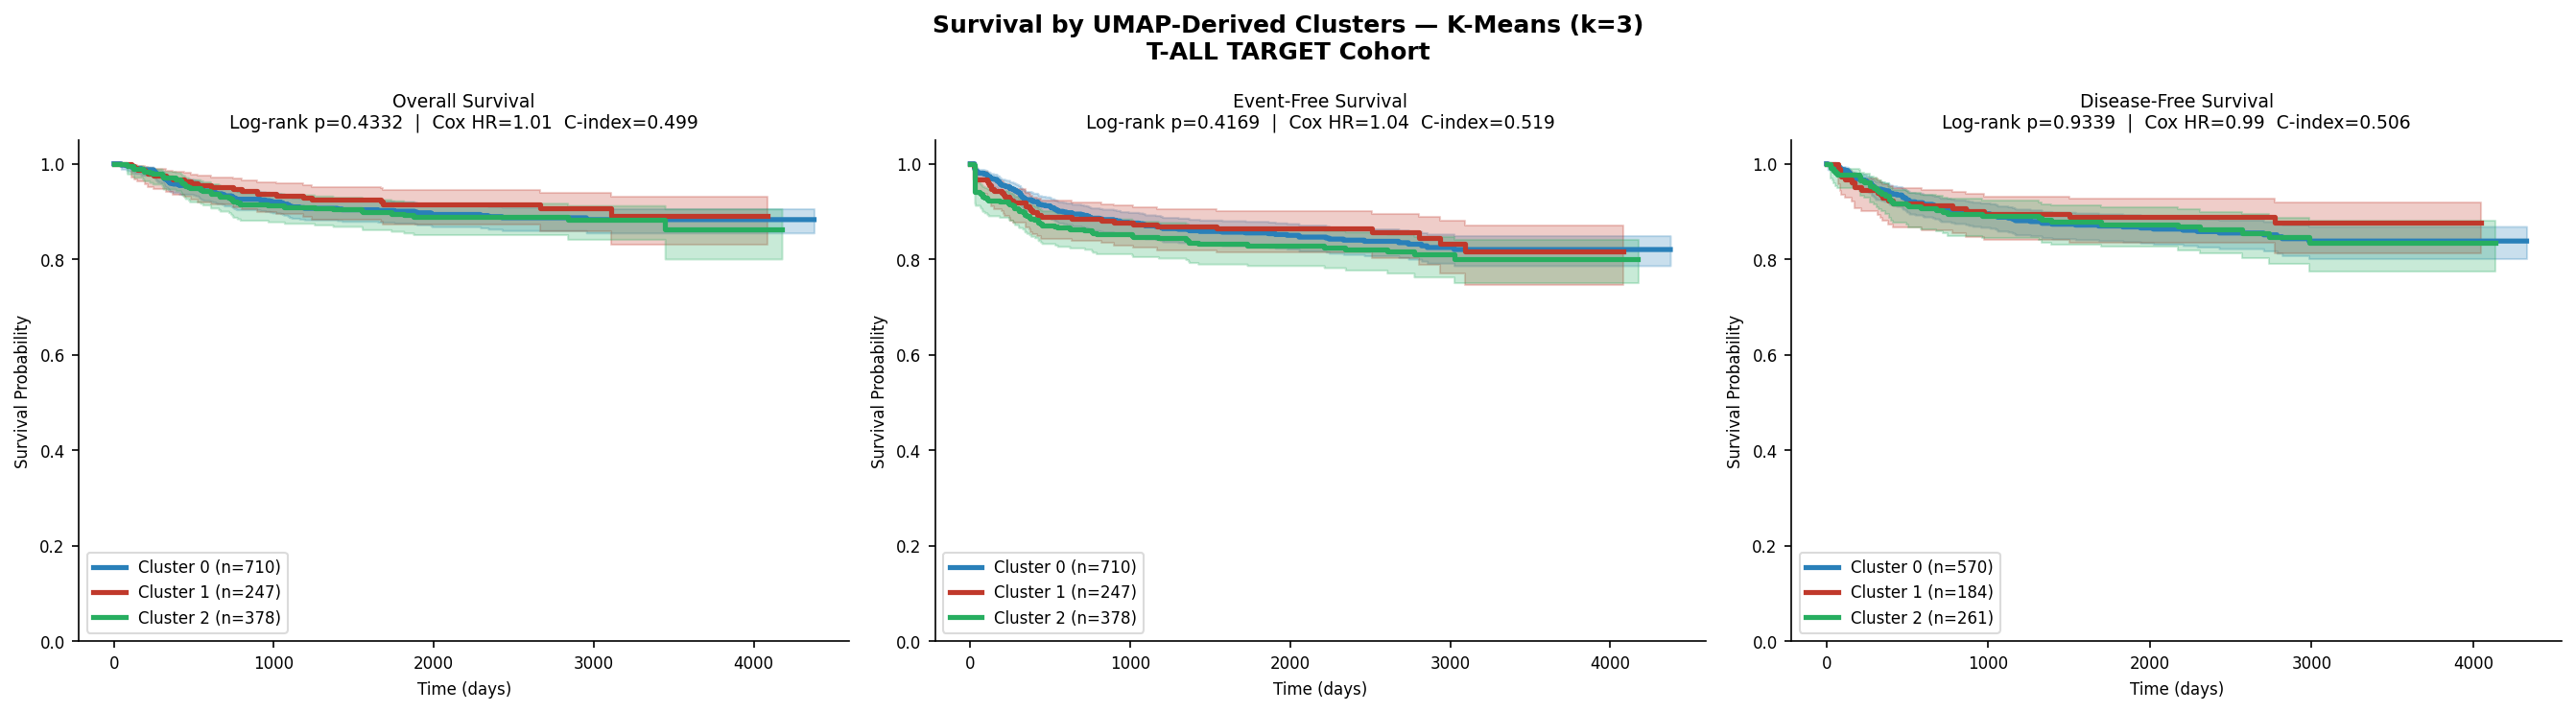

  KM plot → TARGET_umap_outputs/05_km_curves_kmeans_cluster.png

  HDBSCAN (min=10) | Overall Survival: log-rank p=0.1130
  HDBSCAN (min=10) | Event-Free Survival: log-rank p=0.1031
  HDBSCAN (min=10) | Disease-Free Survival: log-rank p=0.8633


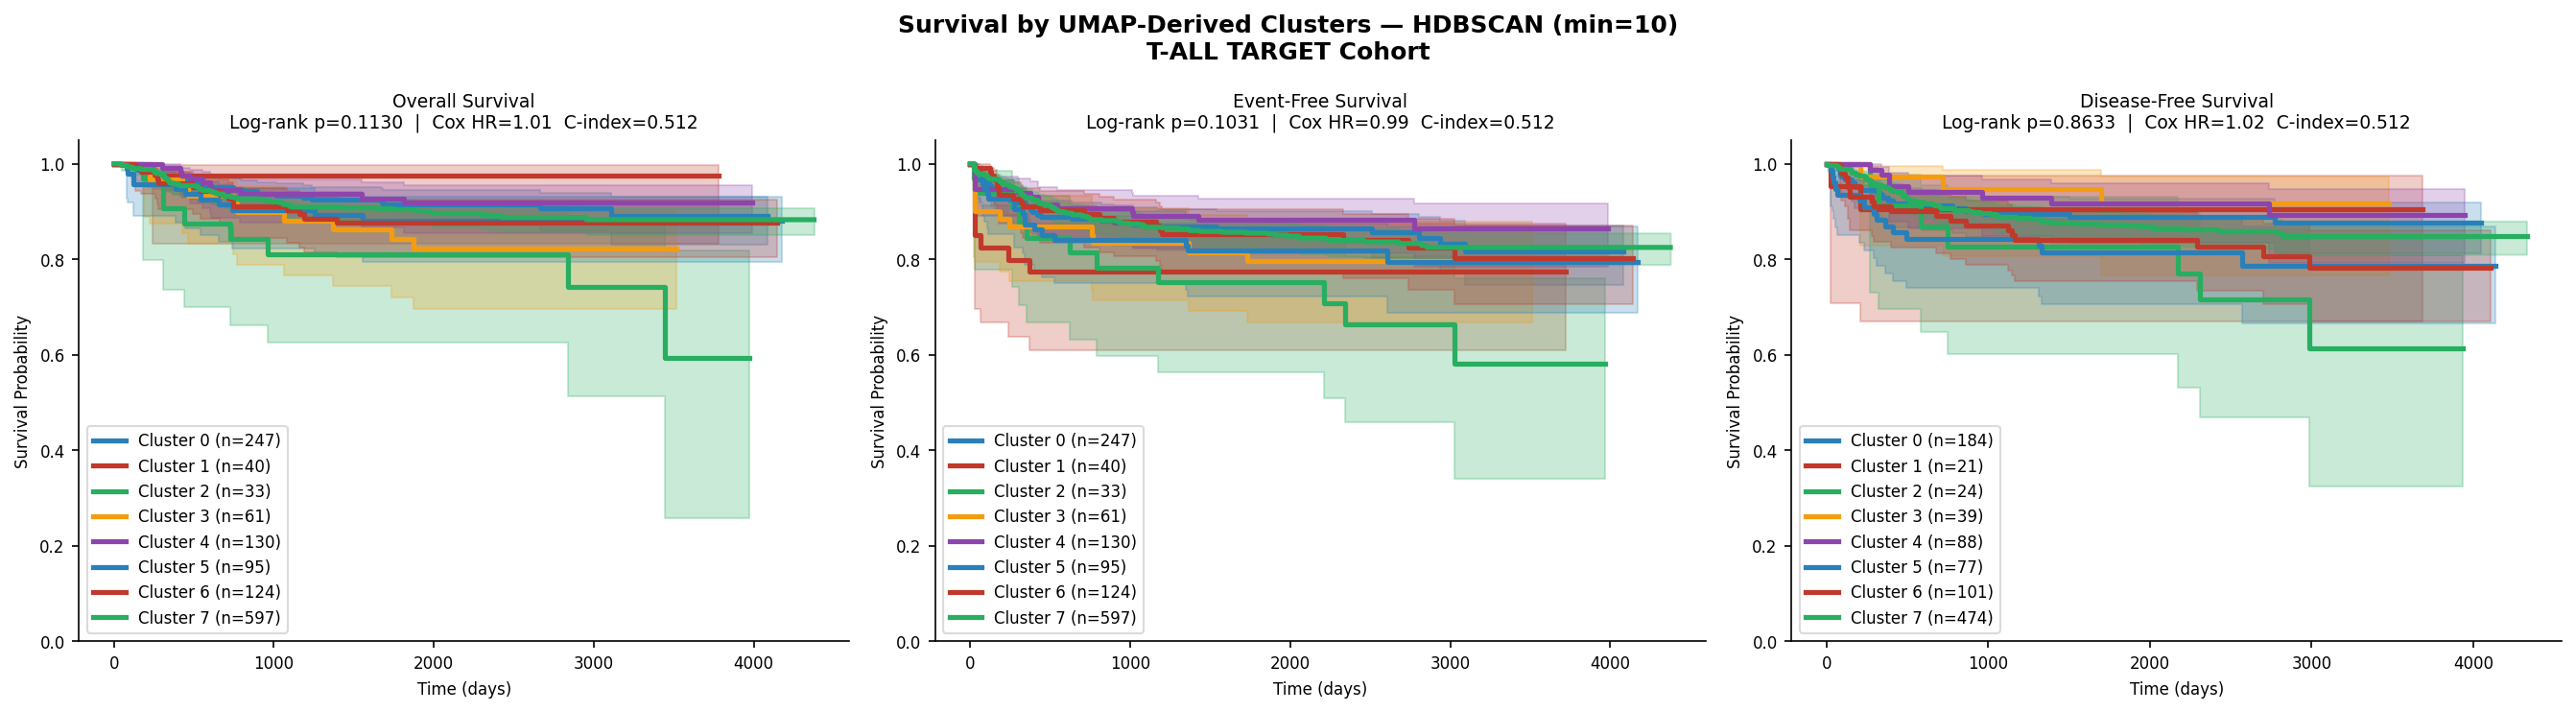

  KM plot → TARGET_umap_outputs/05_km_curves_hdbscan_cluster.png



In [23]:
def cluster_survival_analysis(df_in, cluster_col, duration_col,
                               event_col, endpoint_label, ax, output_dir):
    """
    KM curves for each cluster + log-rank test + Cox HR annotation.
    Returns log-rank p-value.
    """
    subset = df_in[[cluster_col, duration_col, event_col]].dropna()
 
    # Exclude HDBSCAN noise (-1) from survival analysis
    if cluster_col == "HDBSCAN_cluster":
        subset = subset[subset[cluster_col] != -1]
 
    clusters = sorted(subset[cluster_col].unique())
    kmf = KaplanMeierFitter()
    COLORS = ['#2980B9', '#C0392B', '#27AE60', '#F39C12', '#8E44AD']
 
    for idx, cl in enumerate(clusters):
        mask = subset[cluster_col] == cl
        n    = mask.sum()
        kmf.fit(subset.loc[mask, duration_col],
                event_observed=subset.loc[mask, event_col],
                label=f"Cluster {cl} (n={n})")
        kmf.plot_survival_function(ax=ax, ci_show=True,
                                   color=COLORS[idx % len(COLORS)],
                                   linewidth=2.5)
 
    # Log-rank test
    mlr = multivariate_logrank_test(subset[duration_col],
                                     subset[cluster_col],
                                     event_col=subset[event_col])
    p_lr = mlr.p_value
 
    # Cox HR for cluster variable
    try:
        cph = CoxPHFitter(penalizer=0.1)
        cph.fit(subset, duration_col=duration_col,
                event_col=event_col, formula=cluster_col)
        c_idx = cph.concordance_index_
        hr_summary = cph.summary[['exp(coef)', 'exp(coef) lower 95%',
                                   'exp(coef) upper 95%', 'p']].round(3)
        hr_text = (f"Cox HR={hr_summary['exp(coef)'].values[0]:.2f}  "
                   f"C-index={c_idx:.3f}")
    except Exception:
        hr_text = ""
 
    ax.set_title(f"{endpoint_label}\n"
                 f"Log-rank p={p_lr:.4f}  |  {hr_text}",
                 fontsize=9)
    ax.set_xlabel("Time (days)", fontsize=8)
    ax.set_ylabel("Survival Probability", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, framealpha=0.7)
    ax.tick_params(labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)
 
    return p_lr
 
 
# ── Run survival analysis for both cluster methods × all endpoints ──
for cluster_col, cluster_label in [
        ("KMeans_cluster",  f"K-Means (k={BEST_K})"),
        ("HDBSCAN_cluster", f"HDBSCAN (min={HDBSCAN_MIN_CLUSTER})")]:
 
    n_ep = len(ALL_ENDPOINTS)
    fig, axes = plt.subplots(1, n_ep, figsize=(n_ep * 6, 5))
    if n_ep == 1:
        axes = [axes]
 
    for ax, (dur, evt, ep_label) in zip(axes, ALL_ENDPOINTS):
        if dur not in df_model.columns or evt not in df_model.columns:
            ax.set_visible(False)
            continue
        p = cluster_survival_analysis(
            df_model, cluster_col, dur, evt, ep_label, ax, OUTPUT_DIR)
        sig_note = " ✓ SIGNIFICANT" if p < 0.05 else ""
        print(f"  {cluster_label} | {ep_label}: log-rank p={p:.4f}{sig_note}")
 
    safe_cl = cluster_col.lower()
    plt.suptitle(
        f"Survival by UMAP-Derived Clusters — {cluster_label}\n"
        f"T-ALL TARGET Cohort",
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()
    plt.savefig(f"{OUTPUT_DIR}/05_km_curves_{safe_cl}.png",
                bbox_inches='tight', dpi=150)
    plt.close()
    print(f"  KM plot → {OUTPUT_DIR}/05_km_curves_{safe_cl}.png\n")

In [24]:
print("\n" + "=" * 70)
print("STEP 6: WHAT DRIVES UMAP LAYOUT")
print("=" * 70)


STEP 6: WHAT DRIVES UMAP LAYOUT


  Spearman correlation with UMAP axes (top drivers):
                                   display  r_UMAP1  r_UMAP2  max_abs_r
                                       Sex    0.677    0.484      0.677
                                   WBC log    0.263   -0.558      0.558
                                ETP STATUS    0.452   -0.305      0.452
    Percent Blasts Tumor Sample Diagnostic    0.256   -0.437      0.437
                 Age at Diagnosis in Years   -0.211    0.140      0.211
Germline with Tumor Contamination % Blasts    0.021   -0.023      0.023
                      Had Relapse Specimen      NaN      NaN        NaN

  Features significantly different across clusters (Kruskal-Wallis):
    ['WBC log', 'Percent Blasts Tumor Sample Diagnostic', 'Sex', 'ETP STATUS', 'Age at Diagnosis in Years']


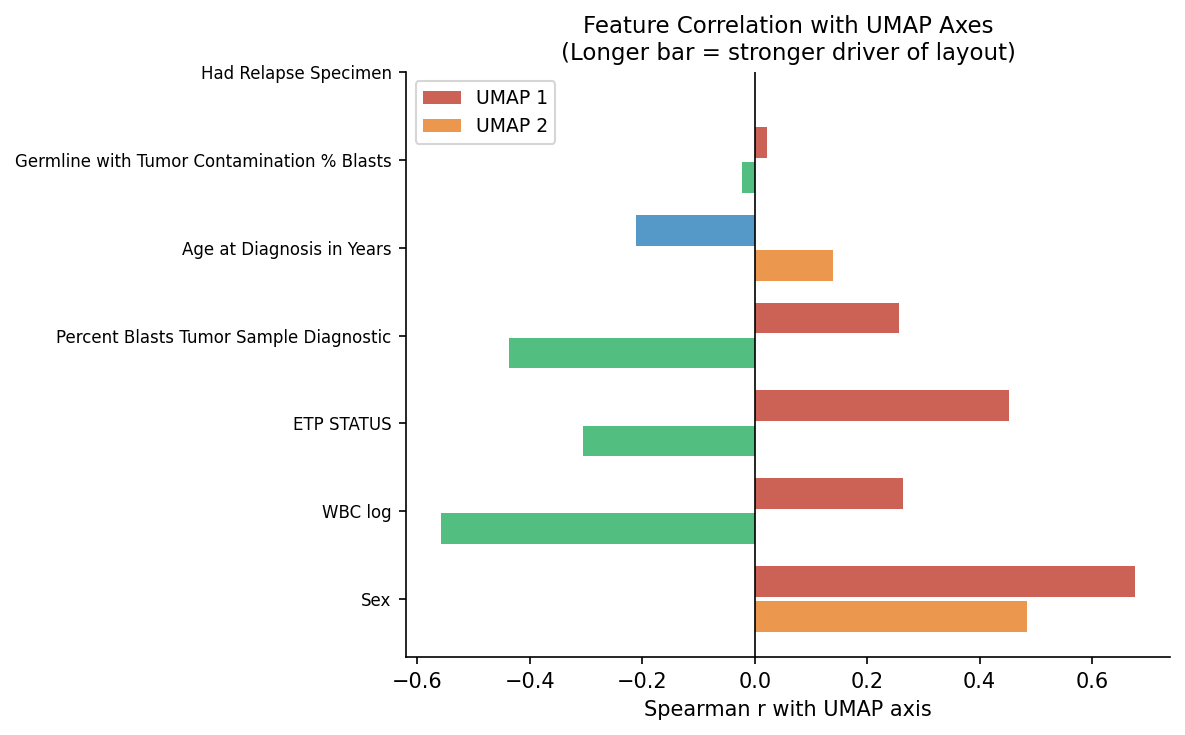


  Feature importance plot → TARGET_umap_outputs/06_umap_feature_importance.png
  Cluster feature boxplots → TARGET_umap_outputs/06_cluster_feature_boxplots.png


In [25]:
from scipy.stats import spearmanr, kruskal
 
# ── 6a. Correlation with UMAP axes ──
umap_corr = []
for col in feature_cols:
    values = X_imputed[col].values
    r1, p1 = spearmanr(values, df_model["UMAP1"])
    r2, p2 = spearmanr(values, df_model["UMAP2"])
    umap_corr.append({
        "variable": col,
        "display": col.replace(".", " ").replace("_", " "),
        "r_UMAP1": round(r1, 3), "p_UMAP1": round(p1, 4),
        "r_UMAP2": round(r2, 3), "p_UMAP2": round(p2, 4),
        "max_abs_r": round(max(abs(r1), abs(r2)), 3),
    })
 
corr_df = pd.DataFrame(umap_corr).sort_values("max_abs_r", ascending=False)
corr_df.to_csv(f"{OUTPUT_DIR}/06_umap_feature_correlations.csv", index=False)
print("  Spearman correlation with UMAP axes (top drivers):")
print(corr_df[["display", "r_UMAP1", "r_UMAP2", "max_abs_r"]].head(10).to_string(index=False))
 
# ── 6b. Kruskal-Wallis across K-Means clusters ──
kw_results = []
for col in feature_cols:
    groups = [X_imputed.loc[df_model["KMeans_cluster"] == cl, col].values
              for cl in sorted(df_model["KMeans_cluster"].unique())]
    groups = [g for g in groups if len(g) >= 3]
    if len(groups) < 2:
        continue
    try:
        stat, p = kruskal(*groups)
        kw_results.append({
            "variable": col,
            "display": col.replace(".", " ").replace("_", " "),
            "kruskal_stat": round(stat, 3),
            "p_value": round(p, 4),
            "significant": p < 0.05,
        })
    except Exception:
        pass
 
kw_df = pd.DataFrame(kw_results).sort_values("p_value")
kw_df.to_csv(f"{OUTPUT_DIR}/06_cluster_feature_differences.csv", index=False)
sig_drivers = kw_df[kw_df['significant']]['display'].tolist()
print(f"\n  Features significantly different across clusters (Kruskal-Wallis):")
print(f"    {sig_drivers}")
 
# ── 6c. Bubble chart: UMAP axis correlations ──
fig, ax = plt.subplots(figsize=(8, max(5, len(corr_df) * 0.45 + 1.5)))
y_pos = range(len(corr_df))
colors_r1 = ['#C0392B' if r > 0 else '#2980B9' for r in corr_df['r_UMAP1']]
colors_r2 = ['#E67E22' if r > 0 else '#27AE60' for r in corr_df['r_UMAP2']]
 
ax.barh([y + 0.2 for y in y_pos], corr_df['r_UMAP1'],
        height=0.35, color=colors_r1, alpha=0.8, label='UMAP 1')
ax.barh([y - 0.2 for y in y_pos], corr_df['r_UMAP2'],
        height=0.35, color=colors_r2, alpha=0.8, label='UMAP 2')
 
ax.set_yticks(list(y_pos))
ax.set_yticklabels(corr_df['display'], fontsize=8)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel("Spearman r with UMAP axis")
ax.set_title("Feature Correlation with UMAP Axes\n"
             "(Longer bar = stronger driver of layout)",
             fontsize=11)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
plt.savefig(f"{OUTPUT_DIR}/06_umap_feature_importance.png",
            bbox_inches='tight', dpi=150)
plt.close()
print(f"\n  Feature importance plot → {OUTPUT_DIR}/06_umap_feature_importance.png")
 
# ── 6d. Box plots: feature distributions by cluster ──
# Show only significant features (Kruskal-Wallis p<0.05)
sig_feat_cols = kw_df[kw_df['significant']]['variable'].tolist()
if sig_feat_cols:
    n_sig = len(sig_feat_cols)
    ncols = min(4, n_sig)
    nrows = int(np.ceil(n_sig / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(ncols * 4, nrows * 3.5))
    axes = np.array(axes).flatten() if n_sig > 1 else [axes]
 
    for i, col in enumerate(sig_feat_cols):
        for cl_id in sorted(df_model["KMeans_cluster"].unique()):
            data = X_imputed.loc[df_model["KMeans_cluster"] == cl_id, col]
            axes[i].boxplot(data.dropna().values,
                            positions=[cl_id],
                            patch_artist=True,
                            boxprops=dict(
                                facecolor=CLUSTER_COLORS[cl_id % len(CLUSTER_COLORS)],
                                alpha=0.7),
                            medianprops=dict(color='black', lw=2),
                            whiskerprops=dict(lw=1.5),
                            widths=0.6)
 
        p_kw = kw_df[kw_df['variable'] == col]['p_value'].values[0]
        display = col.replace(".", " ").replace("_", " ")
        axes[i].set_title(f"{display}\nKruskal-Wallis p={p_kw:.4f}",
                          fontsize=8)
        axes[i].set_xlabel("Cluster", fontsize=7)
        axes[i].set_xticks(sorted(df_model["KMeans_cluster"].unique()))
 
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
 
    plt.suptitle(f"Feature Distributions by K-Means Cluster (k={BEST_K})",
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/06_cluster_feature_boxplots.png",
                bbox_inches='tight', dpi=150)
    plt.close()
    print(f"  Cluster feature boxplots → {OUTPUT_DIR}/06_cluster_feature_boxplots.png")

In [26]:
export_cols = (["USI"] if "USI" in df_model.columns else []) + \
              ["UMAP1", "UMAP2", "KMeans_cluster", "HDBSCAN_cluster"] + \
              [PRIMARY_DURATION, PRIMARY_EVENT] + \
              feature_cols
 
export_cols = [c for c in export_cols if c in df_model.columns]
export_df   = df_model[export_cols].copy()
export_df.to_csv(f"{OUTPUT_DIR}/07_umap_results_full.csv", index=False)
print(f"  Full UMAP results → {OUTPUT_DIR}/07_umap_results_full.csv")
 
# ── 7b. Cluster label lookup (for merging) ──
id_col = "USI" if "USI" in df_model.columns else df_model.index.name
cluster_lookup = df_model[
    ([id_col] if id_col in df_model.columns else []) +
    ["KMeans_cluster", "HDBSCAN_cluster"]
].copy()
cluster_lookup.to_csv(f"{OUTPUT_DIR}/07_cluster_labels.csv", index=False)
print(f"  Cluster label lookup → {OUTPUT_DIR}/07_cluster_labels.csv")
 
# ── 7c. Cluster summary ──
summary_rows = []
for cl_id in sorted(df_model["KMeans_cluster"].unique()):
    mask = df_model["KMeans_cluster"] == cl_id
    row  = {"cluster": cl_id, "n": mask.sum()}
 
    for dur, evt, ep_label in ALL_ENDPOINTS:
        if evt in df_model.columns:
            row[f"{ep_label}_event_rate_%"] = round(
                df_model.loc[mask, evt].mean() * 100, 1)
        if dur in df_model.columns:
            row[f"median_{ep_label}_days"] = round(
                df_model.loc[mask, dur].median(), 0)
 
    for col in feature_cols:
        vals = X_imputed.loc[mask, col].dropna()
        row[f"{col}_median"] = round(vals.median(), 2)
 
    summary_rows.append(row)
 
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(f"{OUTPUT_DIR}/07_cluster_summary.csv", index=False)
print(f"  Cluster summary table → {OUTPUT_DIR}/07_cluster_summary.csv")
print()
print("  Cluster Summary:")
print(summary_df[[c for c in summary_df.columns
                   if 'event_rate' in c or c in ['cluster','n']]].to_string(index=False))

print("This is a clinical-variable UMAP of the TARGET T-ALL cohort, coloured by survival outcomes")
print("It looks at whether clinical features at diagnosis cluster into prognostically distinct groups")

  Full UMAP results → TARGET_umap_outputs/07_umap_results_full.csv
  Cluster label lookup → TARGET_umap_outputs/07_cluster_labels.csv
  Cluster summary table → TARGET_umap_outputs/07_cluster_summary.csv

  Cluster Summary:
 cluster   n  Overall Survival_event_rate_%  Event-Free Survival_event_rate_%  Disease-Free Survival_event_rate_%
       0 710                           10.8                              16.2                                14.6
       1 247                            8.9                              15.0                                11.4
       2 378                           11.1                              18.0                                14.2
This is a clinical-variable UMAP of the TARGET T-ALL cohort, coloured by survival outcomes
It looks at whether clinical features at diagnosis cluster into prognostically distinct groups


In [27]:
print("\n" + "=" * 70)
print("UMAP PIPELINE COMPLETE — SUMMARY")
print("=" * 70)
print(f"  Patients analysed        : {len(df_model)}")
print(f"  Features used            : {len(feature_cols)}")
print(f"  UMAP configurations tested: {len(UMAP_CONFIGS)}")
print(f"  Primary embedding        : {PRIMARY_CONFIG} (n_neighbors=15, min_dist=0.1)")
print(f"  Best K-Means k           : {BEST_K}")
print(f"  HDBSCAN clusters         : {n_hdb_clusters} "
      f"({n_noise} noise points)")
print()
print("  Files written to:", OUTPUT_DIR)
outputs = [
    "01_pca_scree.png",
    "02_umap_config_comparison.png",
    "03_cluster_optimisation.png",
    "04_umap_clinical_overlays.png",
    "04_umap_clusters.png",
    "05_km_curves_kmeans_cluster.png",
    "05_km_curves_hdbscan_cluster.png",
    "06_umap_feature_correlations.csv",
    "06_cluster_feature_differences.csv",
    "06_umap_feature_importance.png",
    "06_cluster_feature_boxplots.png",
    "07_umap_results_full.csv",
    "07_cluster_labels.csv",
    "07_cluster_summary.csv",
]
for f in outputs:
    print(f"  ├── {f}")
 
print()
print("  NEXT STEPS:")
print("  1. Check 04_umap_clusters.png — do clusters look biologically real?")
print("  2. Check 05_km_curves_*.png — do clusters stratify survival?")
print("     → If yes: add 'KMeans_cluster' as a variable in multivariate Cox")
print("  3. Check 06_umap_feature_importance.png — which features drive layout?")
print("     → Validates which Cox-significant variables carry the most signal")
print("  4. Merge 07_cluster_labels.csv with your data before running LASSO Cox")
print()
print("  NEXT SCRIPT → Multivariate Cox Regression (Python)")
print("  THEN        → LASSO Cox Regression (R)")
print("=" * 70)


UMAP PIPELINE COMPLETE — SUMMARY
  Patients analysed        : 1335
  Features used            : 7
  UMAP configurations tested: 4
  Primary embedding        : default (n_neighbors=15, min_dist=0.1)
  Best K-Means k           : 3
  HDBSCAN clusters         : 8 (8 noise points)

  Files written to: TARGET_umap_outputs
  ├── 01_pca_scree.png
  ├── 02_umap_config_comparison.png
  ├── 03_cluster_optimisation.png
  ├── 04_umap_clinical_overlays.png
  ├── 04_umap_clusters.png
  ├── 05_km_curves_kmeans_cluster.png
  ├── 05_km_curves_hdbscan_cluster.png
  ├── 06_umap_feature_correlations.csv
  ├── 06_cluster_feature_differences.csv
  ├── 06_umap_feature_importance.png
  ├── 06_cluster_feature_boxplots.png
  ├── 07_umap_results_full.csv
  ├── 07_cluster_labels.csv
  ├── 07_cluster_summary.csv

  NEXT STEPS:
  1. Check 04_umap_clusters.png — do clusters look biologically real?
  2. Check 05_km_curves_*.png — do clusters stratify survival?
     → If yes: add 'KMeans_cluster' as a variable in mult